In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import tqdm.notebook as tqdm
sns.set()

In [2]:
data_path = '/home/dink/Documents/Research/data/wildfire_case_studies/Holiday_Farm/'
files = os.listdir(data_path)
csv_files = list(filter(lambda f: f.endswith('.csv'), files))
csv_files = list(filter(lambda f: "Primary" in f, files))

In [3]:
dfs = []
for f in csv_files:
    csv = pd.read_csv(os.path.join(data_path, f), usecols=['created_at', 'PM2.5_ATM_ug/m3'])
    dfs.append(csv)
    #print(csv.shape)
    #print(csv.isnull().sum())
len(dfs)

19

In [9]:
dfs[2].shape

(131440, 2)

In [4]:
keep_dfs = []
for i, df in enumerate(dfs):
    start_date = pd.to_datetime(df.loc[:, 'created_at'].values[0])
    print(start_date)
    if start_date == pd.to_datetime("2020-03-01 00:00:00+00:00"):
        print("Keep")
        keep_dfs.append(df)
len(keep_dfs)

2020-03-01 00:00:00+00:00
Keep
2020-03-01 00:00:00+00:00
Keep
2020-03-01 00:01:32+00:00
2020-03-01 00:00:00+00:00
Keep
2020-03-01 00:01:29+00:00
2020-03-01 00:00:00+00:00
Keep
2020-03-01 00:00:00+00:00
Keep
2020-03-01 00:00:00+00:00
Keep
2020-03-01 00:00:00+00:00
Keep
2020-03-01 03:13:20+00:00
2020-03-01 00:00:03+00:00
2020-03-01 00:00:00+00:00
Keep
2020-03-01 00:00:00+00:00
Keep
2020-03-01 00:00:00+00:00
Keep
2020-03-01 00:00:00+00:00
Keep
2020-03-01 00:00:00+00:00
Keep
2020-03-01 00:00:00+00:00
Keep
2020-03-01 00:00:00+00:00
Keep
2020-03-01 00:00:06+00:00


14

In [5]:
earliest_end_date = pd.to_datetime("2020-09-10 00:00:00")
for i, df in enumerate(keep_dfs):
    print(i)
    df.loc[:, 'created_at'] = pd.to_datetime(df.loc[:, 'created_at'].values)
    start_date = pd.to_datetime(df.loc[:, 'created_at'].values[0])
    end_date = pd.to_datetime(df.loc[:, 'created_at'].values[-1])
    if end_date < earliest_end_date:
        earliest_end_date = end_date

0
1
2
3
4
5
6
7
8
9
10
11
12
13


In [6]:
earliest_end_date

Timestamp('2020-09-08 04:00:00')

In [7]:
for i, df in enumerate(keep_dfs):
    indxs = df['created_at'].values <= earliest_end_date
    keep_dfs[i] = df[indxs]

In [8]:
for i, df in enumerate(keep_dfs):
    keep_dfs[i] = df.set_index('created_at')
    keep_dfs[i].index = keep_dfs[i].index.tz_localize(None)
    keep_dfs[i] = keep_dfs[i][~keep_dfs[i].index.duplicated(keep='first')]

In [9]:
for i, df in enumerate(keep_dfs):
    print(keep_dfs[i].shape)

(17790, 1)
(14445, 1)
(15897, 1)
(18353, 1)
(18353, 1)
(18353, 1)
(15897, 1)
(18152, 1)
(17798, 1)
(17790, 1)
(14445, 1)
(18152, 1)
(18353, 1)
(17799, 1)


In [10]:
temp = keep_dfs[0].join(keep_dfs[1], how='outer', lsuffix='_1', rsuffix='_2')
for i in range(2, len(keep_dfs)):
    temp = temp.join(keep_dfs[i], how='outer', lsuffix='_{}'.format(i), rsuffix='_{}'.format(i+1))
temp = temp[~temp.index.duplicated(keep='first')]
temp

,PM2.5_ATM_ug/m3_1,PM2.5_ATM_ug/m3_2,PM2.5_ATM_ug/m3_3,PM2.5_ATM_ug/m3_4,PM2.5_ATM_ug/m3_5,PM2.5_ATM_ug/m3_6,PM2.5_ATM_ug/m3_7,PM2.5_ATM_ug/m3_8,PM2.5_ATM_ug/m3_9,PM2.5_ATM_ug/m3_10,PM2.5_ATM_ug/m3_11,PM2.5_ATM_ug/m3_12,PM2.5_ATM_ug/m3_13,PM2.5_ATM_ug/m3_14
created_at,,,,,,,,,,,,,,
2020-03-01 00:00:00,1.67,0.90,0.33,0.26,0.14,0.86,0.11,0.98,0.15,1.81,0.81,1.22,1.02,0.14
2020-03-01 00:15:00,0.15,2.23,0.19,0.57,0.31,1.69,0.08,0.37,0.01,0.06,2.01,0.50,0.26,0.06
2020-03-01 00:30:00,0.04,0.95,0.81,3.42,3.86,7.66,0.32,0.22,0.00,0.04,0.80,0.24,0.07,0.01
2020-03-01 00:45:00,0.12,0.20,0.54,1.83,1.85,0.14,0.26,3.04,0.00,0.18,0.06,3.56,0.10,0.01
2020-03-01 01:00:00,0.25,0.04,2.14,0.76,0.42,2.19,1.43,2.64,0.00,0.31,0.07,2.97,1.07,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-09-08 03:00:00,308.73,172.44,175.76,263.28,271.60,156.11,3333.37,106.30,52.04,313.45,156.10,102.19,154.54,52.85
2020-09-08 03:15:00,313.29,138.43,160.23,237.74,247.00,136.05,3331.97,107.21,69.36,314.69,125.89,100.70,135.32,69.36
2020-09-08 03:30:00,297.46,130.99,135.78,NaN,NaN,129.56,3331.70,101.67,NaN,300.21,120.05,95.84,126.68,NaN


In [11]:
full_data = temp.interpolate(method='linear')
full_data.isnull().sum()

PM2.5_ATM_ug/m3_1     0
PM2.5_ATM_ug/m3_2     0
PM2.5_ATM_ug/m3_3     0
PM2.5_ATM_ug/m3_4     0
PM2.5_ATM_ug/m3_5     0
PM2.5_ATM_ug/m3_6     0
PM2.5_ATM_ug/m3_7     0
PM2.5_ATM_ug/m3_8     0
PM2.5_ATM_ug/m3_9     0
PM2.5_ATM_ug/m3_10    0
PM2.5_ATM_ug/m3_11    0
PM2.5_ATM_ug/m3_12    0
PM2.5_ATM_ug/m3_13    0
PM2.5_ATM_ug/m3_14    0
dtype: int64

In [14]:
full_data.max(axis=0)

PM2.5_ATM_ug/m3_1      313.29
PM2.5_ATM_ug/m3_2      212.44
PM2.5_ATM_ug/m3_3      184.77
PM2.5_ATM_ug/m3_4      273.47
PM2.5_ATM_ug/m3_5      281.61
PM2.5_ATM_ug/m3_6      186.65
PM2.5_ATM_ug/m3_7     4221.89
PM2.5_ATM_ug/m3_8      210.07
PM2.5_ATM_ug/m3_9       69.36
PM2.5_ATM_ug/m3_10     314.69
PM2.5_ATM_ug/m3_11     192.04
PM2.5_ATM_ug/m3_12     202.47
PM2.5_ATM_ug/m3_13     187.97
PM2.5_ATM_ug/m3_14      69.36
dtype: float64

In [15]:
full_data_clean = full_data.drop("PM2.5_ATM_ug/m3_7", axis=1)
full_data_clean.max(axis=0)

PM2.5_ATM_ug/m3_1     313.29
PM2.5_ATM_ug/m3_2     212.44
PM2.5_ATM_ug/m3_3     184.77
PM2.5_ATM_ug/m3_4     273.47
PM2.5_ATM_ug/m3_5     281.61
PM2.5_ATM_ug/m3_6     186.65
PM2.5_ATM_ug/m3_8     210.07
PM2.5_ATM_ug/m3_9      69.36
PM2.5_ATM_ug/m3_10    314.69
PM2.5_ATM_ug/m3_11    192.04
PM2.5_ATM_ug/m3_12    202.47
PM2.5_ATM_ug/m3_13    187.97
PM2.5_ATM_ug/m3_14     69.36
dtype: float64

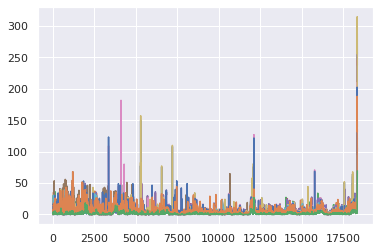

In [17]:
plt.plot(full_data_clean.values);

In [19]:
full_data_clean.to_csv(os.path.join(data_path, "holiday_farm_clean.csv"))